In [ ]:
# Polymarket Test
from src.handlers.polymarket import PolymarketHandler
from src.utils.utils import *
from dotenv import load_dotenv
import psycopg2
from psycopg2 import OperationalError
import copy
import requests
from datetime import datetime
from huggingface_hub import list_repo_files, hf_hub_download, login
import pprint
import time
import duckdb
import random
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

import os

# Load environment variables
load_dotenv()

# Make a PolymarketHandler instance
polymarketHandler = PolymarketHandler(
    polymarketAPIkey = os.getenv("polymarketAPI_key"),
    web3APIkey = os.getenv("alchemyAPI_key"),
    provider = "alchemy"
)


c:\Users\Administrator\Desktop\codes\2-prediction-markets\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
_max = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_018.parquet", "SELECT MAX(block_timestamp) AS largest_value FROM data")).iloc[0,0]
_min = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MIN(block_timestamp) AS largest_value FROM data")).iloc[0,0]
print("time difference with prev batch:", (_min-_max)/60/24, "days")

_max = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_018.parquet", "SELECT MAX(block_number) AS largest_value FROM data")).iloc[0,0]
_min = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MIN(block_number) AS largest_value FROM data")).iloc[0,0]
print("block difference with prev batch:", (_min-_max), "blocks")

_min = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MIN(block_timestamp) AS largest_value FROM data")).iloc[0,0]
_max = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MAX(block_timestamp) AS largest_value FROM data")).iloc[0,0]
print("time difference:", (_max-_min)/60/24, "days")

_min = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MIN(block_number) AS largest_value FROM data")).iloc[0,0]
_max = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MAX(block_number) AS largest_value FROM data")).iloc[0,0]
print("block difference:", (_max-_min), "blocks")

time difference with prev batch: 0.001388888888888889 days
block difference with prev batch: 1 blocks
time difference: 17.77638888888889 days
block difference: 12799 blocks


In [ ]:
allMarkets = pd.DataFrame(queryParquetFile("src/data/polymarket_HistoricalMarkets.parquet", "SELECT * FROM data"))

In [ ]:
filteredmarkets = allMarkets[allMarkets.volumeNum > 1_000_000]

In [ ]:
filteredmarkets.iloc[random.randint(0, filteredmarkets.shape[0])]

slug                fed-decreases-interest-rates-by-50-bps-after-s...
marketID                                                       504069
bestAsk                                                           1.0
bestBid                                                         0.999
outcome_0                                                         Yes
outcome_0_ID        1061913283585765403514392677659254503298594295...
outcome_0_price                                                   1.0
outcome_0_return                                                  0.0
outcome_1                                                          No
outcome_1_ID        9214127416164770663428045171731158534317583924...
outcome_1_price                                                   0.0
outcome_1_return                                                  NaN
spread                                                          0.001
volumeNum                                              10906333.42219
volume1yr           

In [ ]:
def plotOutcomes(dfs, dateRange, wonIndex: int, labels=None, title="Price Comparison",
                  figsize=(12, 6), fidelity=None, showLast = None):
    """
    Plots price data from an arbitrary number of dataframes on a single plot.

    Parameters:
        dfs : list of pd.DataFrame
            Each must have 'block_timestamp' and 'price' columns.
        dateRange : tuple/list of (start, end)
            Start and end datetimes (or timestamps) used to (a) anchor the
            start/finish points added to each series and (b) set the x-axis limits.
        wonIndex : int
            Index into dfs/labels of the winning outcome (its finishing price is set to 1;
            all others finish at 0).
        labels : list of str, optional
            Legend labels for each series. Defaults to "Series 1", "Series 2", ...
        title : str
            Plot title.
        figsize : tuple
            Figure size.
        fidelity : int, optional
            Resampling resolution in minutes, matching Polymarket's `fidelity` parameter
            (e.g. 1, 10, 60, 1440). If provided, each series is resampled/downsampled to
            this granularity (taking the last price in each bucket) before plotting.
        showLast : int
            Only show the last period in seconds
    """
    if labels is None:
        labels = [f"Series {i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Length of labels must match length of dfs")

    startDate = pd.to_datetime(dateRange[0], unit="s") if not isinstance(dateRange[0], pd.Timestamp) else dateRange[0]
    endDate = pd.to_datetime(dateRange[1], unit="s") if not isinstance(dateRange[1], pd.Timestamp) else dateRange[1]

    fig, ax = plt.subplots(figsize=figsize)

    for i, (df, label) in enumerate(zip(dfs, labels)):
        df = df.copy()
        df["block_timestamp"] = pd.to_datetime(df["block_timestamp"], unit="s")
        df = df.sort_values("block_timestamp")
        df = df[["block_timestamp", "price"]]

        # Apply Polymarket-style fidelity (resample to N-minute buckets)
        if fidelity is not None:
            df = (
                df.set_index("block_timestamp")
                  .resample(f"{fidelity}min")
                  .last()
                  .dropna()
                  .reset_index()
            )

        newRow = pd.DataFrame({'block_timestamp': [startDate], 'price': [1/len(dfs)]})
        df = pd.concat([newRow, df], ignore_index=True)

        # Add the finishing point (0 for losers and 1 for winner)
        finishPrice = 1 if i == wonIndex else 0
        newRow = pd.DataFrame({'block_timestamp': [endDate], 'price': [finishPrice]})
        df = pd.concat([df, newRow], ignore_index=True)

        ax.plot(df["block_timestamp"], df["price"], label=label, linewidth=1.5)

    ax.set_xlabel("Time")
    ax.set_ylabel("Price")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Set x-axis to the requested date range
    if showLast:
        ax.set_xlim(max(endDate - pd.Timedelta(seconds=showLast), startDate), endDate)
    else:
        ax.set_xlim(startDate, endDate)

    # Human-readable date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d, %Y"))
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()
    return fig, ax

In [ ]:
xxx = queryParquetFolder("./src/data/polymarketData", f"SELECT MIN(block_number) AS max_value FROM data WHERE block_number <> -1")


In [ ]:
marketData = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_001.parquet", f"SELECT * FROM data WHERE slug = '{slug}'"))

,max_value
0,86126998


In [ ]:
# Plot a polymarket's market 

# Get the market's data - one token ID has to be given
_idx = random.randint(0, filteredmarkets.shape[0])
slug = filteredmarkets.iloc[_idx].slug
marketData = pd.DataFrame(queryParquetFile("src/data/polymarket_HistoricalMarkets.parquet", f"SELECT * FROM data WHERE slug = '{slug}'"))

outcome_0_trades = queryParquetFolder("./src/data/polymarketData", f"SELECT * FROM data WHERE token_id = '{marketData.iloc[0].outcome_0_ID}'")
outcome_1_trades = queryParquetFolder("./src/data/polymarketData", f"SELECT * FROM data WHERE token_id = '{marketData.iloc[0].outcome_1_ID}'")

print(f"Index: {_idx}")
print(f"Slug: {marketData.iloc[0].slug}")
print(f"Market ID: {marketData.iloc[0].marketID}")
print(f"Outcome 0: {marketData.iloc[0].outcome_0} ({marketData.iloc[0].outcome_0_ID[0:10]}...{marketData.iloc[0].outcome_0_ID[-10:]})")
print(f"Outcome 1: {marketData.iloc[0].outcome_1} ({marketData.iloc[0].outcome_1_ID[0:10]}...{marketData.iloc[0].outcome_1_ID[-10:]})")
print(f"Total trades count: {outcome_0_trades.shape[0] + outcome_1_trades.shape[0]:,}")
# print(f"Duration: {(allTrades.iloc[-1].block_timestamp - allTrades.iloc[0].block_timestamp)/60/24}")


Index: 3364
Slug: will-pheu-thai-party-pt-win-the-most-seats-in-the-2026-thai-legislative-election
Market ID: 923043
Outcome 0: Yes (2245001293...6623646569)
Outcome 1: No (5820649956...8365274760)
Total trades count: 0


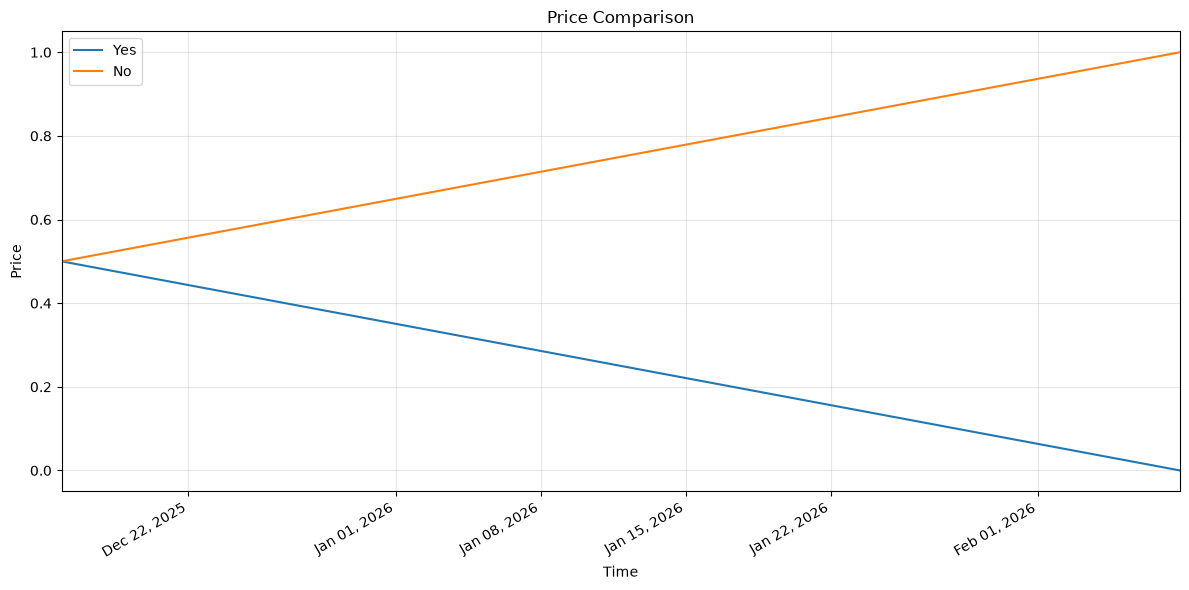

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Price Comparison'}, xlabel='Time', ylabel='Price'>)

In [ ]:
dateRange = [
    int(min(datetime.fromisoformat(marketData.startDate.iloc[0]).timestamp(), outcome_0_trades.block_timestamp.min(), outcome_1_trades.block_timestamp.min())),
    int(max(datetime.fromisoformat(marketData.endDate.iloc[0]).timestamp(), outcome_0_trades.block_timestamp.max(), outcome_1_trades.block_timestamp.max()))
]

wonIndex = 0 if marketData.outcome_0_price.iloc[0] == 1.0 else 1

plotOutcomes(
    dfs = [outcome_0_trades, outcome_1_trades],
    labels = [marketData.iloc[0].outcome_0, marketData.iloc[0].outcome_1],
    dateRange = dateRange,
    wonIndex = wonIndex,
    # showLast = 4 * 60 * 60
    # fidelity = 5
)